# Step 1: Dataset Processing and Loading

Starting efficient data loading...
Getting video paths and labels...
Adding Vox videos to RealVideo-RealAudio class...

Dataset Statistics:
Total videos: 31541
RealVideo-RealAudio: 10500 videos (33.3%)
FakeVideo-FakeAudio: 10832 videos (34.3%)
RealVideo-FakeAudio: 500 videos (1.6%)
FakeVideo-RealAudio: 9709 videos (30.8%)


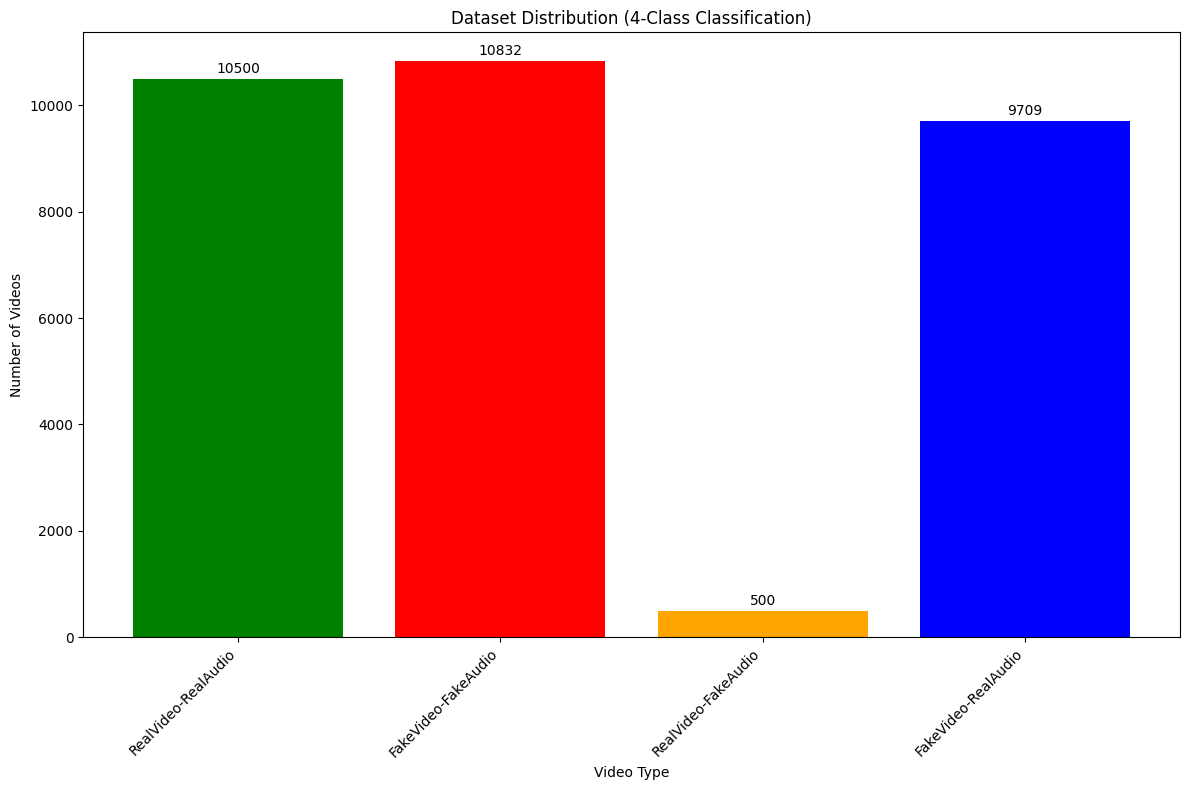

Visualizing sample videos...


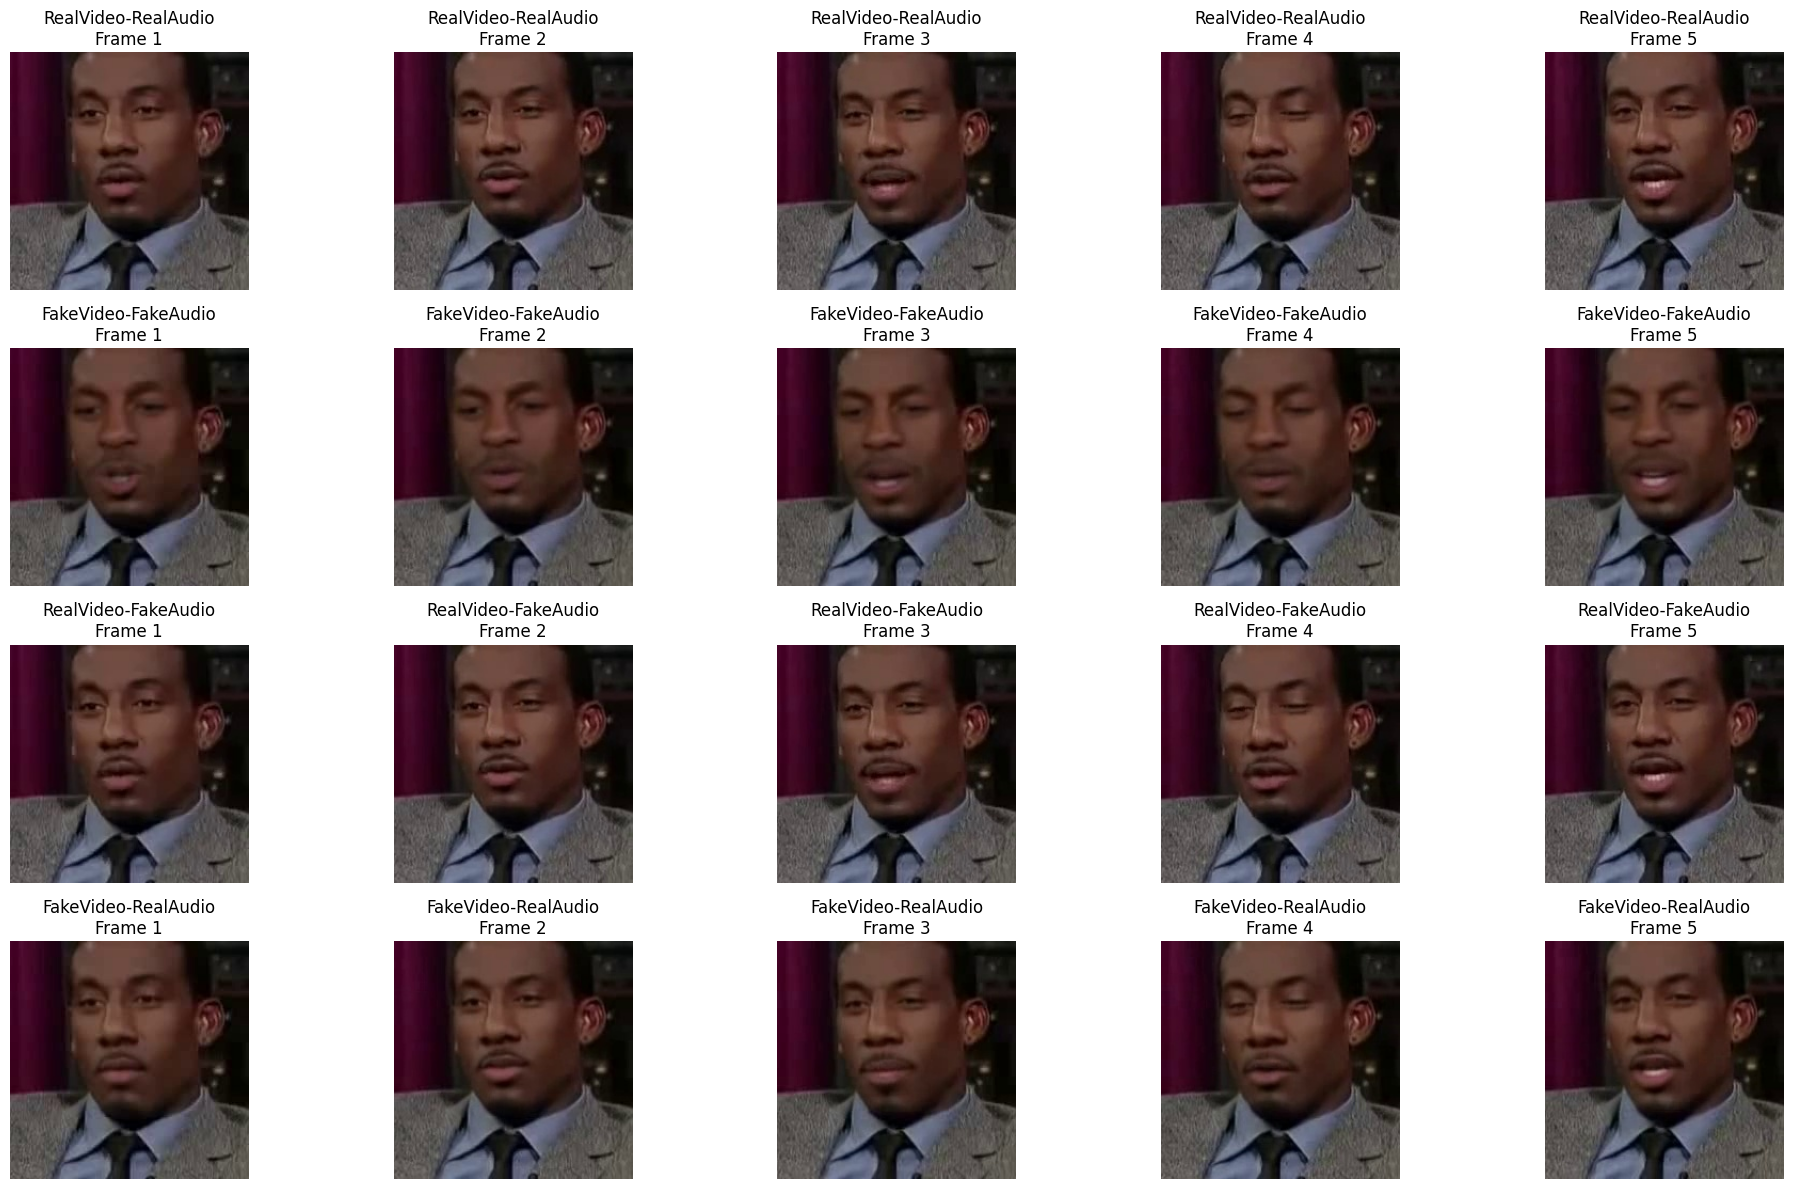

Creating train/validation/test splits...

Dataset Splits:
Train: 22078 videos
Validation: 3154 videos
Test: 6309 videos

Train distribution:
  RealVideo-RealAudio: 7350
  FakeVideo-RealAudio: 6796
  FakeVideo-FakeAudio: 7582
  RealVideo-FakeAudio: 350

Val distribution:
  RealVideo-RealAudio: 1050
  FakeVideo-RealAudio: 971
  FakeVideo-FakeAudio: 1083
  RealVideo-FakeAudio: 50

Test distribution:
  RealVideo-FakeAudio: 100
  FakeVideo-FakeAudio: 2167
  FakeVideo-RealAudio: 1942
  RealVideo-RealAudio: 2100
Saving data for next step...

Data splits saved! Total videos: 31541
Ready for Step 2: Data Generator and Preprocessing


In [3]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from collections import Counter
import cv2
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
import glob

# Set paths
FAKEAV_PATH = "/kaggle/input/fakeav/frames/frames"
VOX_PATH = "/kaggle/input/vox-video"

# Parameters
FRAMES_PER_VIDEO = 30
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 8
NUM_CLASSES = 4  # RealVideo-RealAudio, FakeVideo-FakeAudio, RealVideo-FakeAudio, FakeVideo-RealAudio

# Class mapping
CLASS_NAMES = {
    0: "RealVideo-RealAudio",
    1: "FakeVideo-FakeAudio", 
    2: "RealVideo-FakeAudio",
    3: "FakeVideo-RealAudio"
}

def get_video_paths_and_labels():
    """Get all video paths and create labels efficiently"""
    video_paths = []
    labels = []
    
    print("Collecting video paths...")
    
    # FakeAV categories with their labels
    fakeav_categories = {
        "RealVideo-RealAudio": 0,
        "FakeVideo-FakeAudio": 1,
        "RealVideo-FakeAudio": 2,
        "FakeVideo-RealAudio": 3
    }
    
    # Process FakeAV videos
    for category, label in fakeav_categories.items():
        category_path = os.path.join(FAKEAV_PATH, category)
        if os.path.exists(category_path):
            # Navigate through ethnicity folders
            for ethnicity in os.listdir(category_path):
                ethnicity_path = os.path.join(category_path, ethnicity)
                if os.path.isdir(ethnicity_path):
                    # Navigate through gender folders
                    for gender in os.listdir(ethnicity_path):
                        gender_path = os.path.join(ethnicity_path, gender)
                        if os.path.isdir(gender_path):
                            # Navigate through person ID folders
                            for person_id in os.listdir(gender_path):
                                person_path = os.path.join(gender_path, person_id)
                                if os.path.isdir(person_path):
                                    # Navigate through video folders
                                    for video_folder in os.listdir(person_path):
                                        video_path = os.path.join(person_path, video_folder)
                                        if os.path.isdir(video_path):
                                            # Check if this folder has frames
                                            frames = glob.glob(os.path.join(video_path, "*.jpg"))
                                            if len(frames) >= FRAMES_PER_VIDEO:
                                                video_paths.append(video_path)
                                                labels.append(label)
    
    # Add Vox videos to RealVideo-RealAudio class (label 0) to balance the dataset
    print("Adding Vox videos to RealVideo-RealAudio class...")
    vox_added = 0
    max_vox_videos = 10000  # Limit to 10K as mentioned
    
    for person_id in os.listdir(VOX_PATH):
        if vox_added >= max_vox_videos:
            break
            
        person_path = os.path.join(VOX_PATH, person_id)
        if os.path.isdir(person_path):
            for video_id in os.listdir(person_path):
                if vox_added >= max_vox_videos:
                    break
                    
                video_base_path = os.path.join(person_path, video_id)
                if os.path.isdir(video_base_path):
                    # Check for numbered subdirectories (like 00001, 00002, etc.)
                    for sub_folder in os.listdir(video_base_path):
                        if vox_added >= max_vox_videos:
                            break
                            
                        video_path = os.path.join(video_base_path, sub_folder)
                        if os.path.isdir(video_path):
                            # Check if this folder has frames
                            frames = glob.glob(os.path.join(video_path, "*.jpg"))
                            if len(frames) >= FRAMES_PER_VIDEO:
                                video_paths.append(video_path)
                                labels.append(0)  # Add to RealVideo-RealAudio class
                                vox_added += 1
    
    return video_paths, labels

def display_dataset_stats(video_paths, labels):
    """Display dataset statistics"""
    print("\nDataset Statistics:")
    print("=" * 50)
    
    label_counts = Counter(labels)
    
    total_videos = len(video_paths)
    print(f"Total videos: {total_videos}")
    
    for label, count in label_counts.items():
        percentage = (count / total_videos) * 100
        print(f"{CLASS_NAMES[label]}: {count} videos ({percentage:.1f}%)")
    
    # Plot distribution
    plt.figure(figsize=(12, 8))
    labels_list = list(label_counts.keys())
    counts_list = list(label_counts.values())
    label_names_list = [CLASS_NAMES[l] for l in labels_list]
    
    plt.bar(range(len(label_names_list)), counts_list, color=['green', 'red', 'orange', 'blue'])
    plt.title('Dataset Distribution (4-Class Classification)')
    plt.xlabel('Video Type')
    plt.ylabel('Number of Videos')
    plt.xticks(range(len(label_names_list)), label_names_list, rotation=45, ha='right')
    
    for i, v in enumerate(counts_list):
        plt.text(i, v + max(counts_list) * 0.01, str(v), ha='center')
    
    plt.tight_layout()
    plt.show()
    
    return label_counts

def load_sample_video(video_path, num_frames=FRAMES_PER_VIDEO):
    """Load a sample video to check data format"""
    frames = []
    frame_files = glob.glob(os.path.join(video_path, "*.jpg"))
    frame_files = sorted(frame_files, key=lambda x: int(os.path.basename(x).split('_')[-1].split('.')[0]))
    
    # Take evenly spaced frames if more than required
    if len(frame_files) > num_frames:
        indices = np.linspace(0, len(frame_files) - 1, num_frames).astype(int)
        frame_files = [frame_files[i] for i in indices]
    
    for frame_file in frame_files[:num_frames]:
        frame = cv2.imread(frame_file)
        if frame is not None:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, IMAGE_SIZE)
            frames.append(frame)
    
    return np.array(frames)

def visualize_sample_videos(video_paths, labels):
    """Visualize sample videos from each class"""
    
    # Get one sample from each class
    samples = {}
    for path, label in zip(video_paths, labels):
        if label not in samples:
            samples[label] = path
        if len(samples) == 4:  # All classes found
            break
    
    plt.figure(figsize=(20, 12))
    
    for idx, (label, path) in enumerate(samples.items()):
        video_frames = load_sample_video(path, 5)  # Load 5 frames for visualization
        
        for frame_idx in range(min(5, len(video_frames))):
            plt.subplot(4, 5, idx * 5 + frame_idx + 1)
            plt.imshow(video_frames[frame_idx])
            plt.title(f"{CLASS_NAMES[label]}\nFrame {frame_idx + 1}")
            plt.axis('off')
    
    plt.tight_layout()
    plt.show()

def create_train_test_split(video_paths, labels, test_size=0.2, val_size=0.1):
    """Create train/validation/test splits"""
    
    # Convert to numpy arrays
    video_paths = np.array(video_paths)
    labels = np.array(labels)
    
    # Stratified split to maintain class distribution
    X_temp, X_test, y_temp, y_test = train_test_split(
        video_paths, labels, 
        test_size=test_size, 
        stratify=labels, 
        random_state=42
    )
    
    # Further split temp into train and validation
    val_size_adjusted = val_size / (1 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, 
        test_size=val_size_adjusted, 
        stratify=y_temp, 
        random_state=42
    )
    
    print(f"\nDataset Splits:")
    print(f"Train: {len(X_train)} videos")
    print(f"Validation: {len(X_val)} videos") 
    print(f"Test: {len(X_test)} videos")
    
    # Show class distribution in each split
    for split_name, split_labels in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
        print(f"\n{split_name} distribution:")
        split_counts = Counter(split_labels)
        for label, count in split_counts.items():
            print(f"  {CLASS_NAMES[label]}: {count}")
    
    return X_train, X_val, X_test, y_train, y_val, y_test

# Main execution
if __name__ == "__main__":
    print("Starting efficient data loading...")
    
    # Step 1: Get video paths and labels
    print("Getting video paths and labels...")
    video_paths, labels = get_video_paths_and_labels()
    
    # Step 2: Display statistics
    label_counts = display_dataset_stats(video_paths, labels)
    
    # Step 3: Visualize sample videos
    print("Visualizing sample videos...")
    if len(video_paths) > 0:
        visualize_sample_videos(video_paths, labels)
    
    # Step 4: Create train/test splits
    print("Creating train/validation/test splits...")
    X_train, X_val, X_test, y_train, y_val, y_test = create_train_test_split(video_paths, labels)
    
    # Step 5: Save all data for next step
    print("Saving data for next step...")
    data_info = {
        'X_train': X_train,
        'X_val': X_val, 
        'X_test': X_test,
        'y_train': y_train,
        'y_val': y_val,
        'y_test': y_test,
        'class_names': CLASS_NAMES,
        'label_counts': dict(label_counts)
    }
    
    import pickle
    with open('video_data_splits.pkl', 'wb') as f:
        pickle.dump(data_info, f)
    
    print(f"\nData splits saved! Total videos: {len(video_paths)}")
    print("Ready for Step 2: Data Generator and Preprocessing")

# Step 2: Data Generator and Preprocessing Pipeline

In [6]:
import os
import cv2
import numpy as np
import pickle
import tensorflow as tf
from tensorflow.keras.utils import Sequence
import random
from sklearn.preprocessing import LabelEncoder
import albumentations as A

class VideoDataGenerator(Sequence):
    """
    Custom data generator for video classification with spatial and temporal augmentations
    """
    
    def __init__(self, video_paths, labels, batch_size=8, num_frames=16, 
                 img_size=(224, 224), shuffle=True, augment=True, mode='train'):
        """
        Initialize the data generator
        
        Args:
            video_paths: List of video file paths
            labels: List of corresponding labels
            batch_size: Number of videos per batch
            num_frames: Number of frames to extract per video
            img_size: Target image size (height, width)
            shuffle: Whether to shuffle data between epochs
            augment: Whether to apply augmentations
            mode: 'train', 'val', or 'test'
        """
        self.video_paths = video_paths
        self.labels = labels
        self.batch_size = batch_size
        self.num_frames = num_frames
        self.img_size = img_size
        self.shuffle = shuffle
        self.augment = augment
        self.mode = mode
        
        # Create label encoder
        self.label_encoder = LabelEncoder()
        self.encoded_labels = self.label_encoder.fit_transform(labels)
        self.num_classes = len(self.label_encoder.classes_)
        
        # Initialize indices
        self.indices = np.arange(len(self.video_paths))
        if self.shuffle:
            np.random.shuffle(self.indices)
            
        # Define augmentation pipeline
        self.spatial_augment = self._get_spatial_augmentations()
        
        print(f"Data generator initialized:")
        print(f"  Total samples: {len(self.video_paths)}")
        print(f"  Batch size: {self.batch_size}")
        print(f"  Frames per video: {self.num_frames}")
        print(f"  Image size: {self.img_size}")
        print(f"  Number of classes: {self.num_classes}")
        print(f"  Classes: {list(self.label_encoder.classes_)}")
    
    def _get_spatial_augmentations(self):
        """Define spatial augmentations for training"""
        if self.augment and self.mode == 'train':
            return A.Compose([
                A.HorizontalFlip(p=0.5),
                A.RandomBrightnessContrast(
                    brightness_limit=0.2, 
                    contrast_limit=0.2, 
                    p=0.5
                ),
                A.GaussianBlur(blur_limit=3, p=0.3),
                A.CoarseDropout(
                    max_holes=8,
                    max_height=32,
                    max_width=32,
                    min_holes=1,
                    min_height=8,
                    min_width=8,
                    fill_value=0,
                    p=0.3
                ),
                A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ])
        else:
            return A.Compose([
                A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ])
    
    def __len__(self):
        """Return number of batches per epoch"""
        return len(self.video_paths) // self.batch_size
    
    def __getitem__(self, index):
        """Generate one batch of data"""
        # Get batch indices
        batch_indices = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
        
        # Generate batch
        batch_videos = []
        batch_labels = []
        
        for idx in batch_indices:
            # Load and preprocess video
            video_frames = self._load_video(self.video_paths[idx])
            if video_frames is not None:
                batch_videos.append(video_frames)
                batch_labels.append(self.encoded_labels[idx])
        
        # Convert to numpy arrays
        X = np.array(batch_videos, dtype=np.float32)
        y = tf.keras.utils.to_categorical(batch_labels, num_classes=self.num_classes)
        
        return X, y
    
    def _load_video(self, video_path):
        """
        Load video frames with uniform temporal sampling
        """
        try:
            cap = cv2.VideoCapture(video_path)
            
            # Get total frames
            total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            
            if total_frames < self.num_frames:
                # If video has fewer frames than required, repeat frames
                frame_indices = np.linspace(0, total_frames - 1, self.num_frames, dtype=int)
            else:
                # Uniform sampling
                frame_indices = np.linspace(0, total_frames - 1, self.num_frames, dtype=int)
            
            frames = []
            for frame_idx in frame_indices:
                cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
                ret, frame = cap.read()
                
                if ret:
                    # Convert BGR to RGB
                    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                    
                    # Resize frame
                    frame = cv2.resize(frame, self.img_size)
                    
                    # Apply spatial augmentations
                    if self.spatial_augment:
                        augmented = self.spatial_augment(image=frame)
                        frame = augmented['image']
                    
                    frames.append(frame)
                else:
                    # If frame reading fails, duplicate the last frame
                    if frames:
                        frames.append(frames[-1])
                    else:
                        # Create a black frame if no frames are available
                        black_frame = np.zeros((*self.img_size, 3), dtype=np.uint8)
                        frames.append(black_frame)
            
            cap.release()
            
            # Ensure we have the correct number of frames
            while len(frames) < self.num_frames:
                frames.append(frames[-1] if frames else np.zeros((*self.img_size, 3)))
            
            return np.array(frames[:self.num_frames], dtype=np.float32)
            
        except Exception as e:
            print(f"Error loading video {video_path}: {str(e)}")
            # Return a dummy video with black frames
            return np.zeros((self.num_frames, *self.img_size, 3), dtype=np.float32)
    
    def on_epoch_end(self):
        """Shuffle indices after each epoch"""
        if self.shuffle:
            np.random.shuffle(self.indices)

def create_data_generators(data_splits_path, batch_size=8, num_frames=16, img_size=(224, 224)):
    """
    Create train, validation, and test data generators
    
    Args:
        data_splits_path: Path to the saved data splits pickle file
        batch_size: Batch size for training
        num_frames: Number of frames per video
        img_size: Target image size
    
    Returns:
        train_gen, val_gen, test_gen, label_encoder
    """
    print("Loading data splits...")
    
    # Load the preprocessed data
    with open(data_splits_path, 'rb') as f:
        data_splits = pickle.load(f)
    
    # Extract splits using the correct structure
    train_paths = data_splits['X_train']
    train_labels = data_splits['y_train']
    val_paths = data_splits['X_val']
    val_labels = data_splits['y_val']
    test_paths = data_splits['X_test']
    test_labels = data_splits['y_test']
    
    print(f"Data loaded successfully:")
    print(f"  Train: {len(train_paths)} videos")
    print(f"  Val: {len(val_paths)} videos")
    print(f"  Test: {len(test_paths)} videos")
    print(f"  Classes: {data_splits['class_names']}")
    
    print(f"Creating data generators...")
    
    # Create generators
    train_gen = VideoDataGenerator(
        video_paths=train_paths,
        labels=train_labels,
        batch_size=batch_size,
        num_frames=num_frames,
        img_size=img_size,
        shuffle=True,
        augment=True,
        mode='train'
    )
    
    val_gen = VideoDataGenerator(
        video_paths=val_paths,
        labels=val_labels,
        batch_size=batch_size,
        num_frames=num_frames,
        img_size=img_size,
        shuffle=False,
        augment=False,
        mode='val'
    )
    
    test_gen = VideoDataGenerator(
        video_paths=test_paths,
        labels=test_labels,
        batch_size=batch_size,
        num_frames=num_frames,
        img_size=img_size,
        shuffle=False,
        augment=False,
        mode='test'
    )
    
    return train_gen, val_gen, test_gen, train_gen.label_encoder

# Test the data generator
if __name__ == "__main__":
    # First, let's check the structure of the saved data
    print("Checking data splits structure...")
    
    with open('/kaggle/working/video_data_splits.pkl', 'rb') as f:
        data_splits = pickle.load(f)
    
    print("Keys in data_splits:", list(data_splits.keys()))
    
    # Check the structure and adapt accordingly
    if 'train_data' in data_splits:
        print("Found 'train_data' structure")
        print("Train data keys:", list(data_splits['train_data'].keys()) if isinstance(data_splits['train_data'], dict) else "Not a dict")
        print("Val data keys:", list(data_splits['val_data'].keys()) if isinstance(data_splits['val_data'], dict) else "Not a dict")
        print("Test data keys:", list(data_splits['test_data'].keys()) if isinstance(data_splits['test_data'], dict) else "Not a dict")
        
        # Adapt the data loading
        train_paths = data_splits['train_data']['paths']
        train_labels = data_splits['train_data']['labels']
        val_paths = data_splits['val_data']['paths']
        val_labels = data_splits['val_data']['labels']
        test_paths = data_splits['test_data']['paths']
        test_labels = data_splits['test_data']['labels']
        
    else:
        print("Different structure found. Available keys:", list(data_splits.keys()))
        # Try to identify the correct structure
        for key, value in data_splits.items():
            if isinstance(value, (list, np.ndarray)):
                print(f"{key}: {type(value)}, length: {len(value)}")
            else:
                print(f"{key}: {type(value)}")
    
    print("\nNow testing adapted data generator...")
    
    # Load the data splits
    with open('/kaggle/working/video_data_splits.pkl', 'rb') as f:
        data_splits = pickle.load(f)
    
    # Extract the correct data
    train_paths = data_splits['X_train']
    train_labels = data_splits['y_train']
    val_paths = data_splits['X_val']
    val_labels = data_splits['y_val']
    test_paths = data_splits['X_test']
    test_labels = data_splits['y_test']
    
    print(f"Data loaded:")
    print(f"  Train: {len(train_paths)} videos")
    print(f"  Val: {len(val_paths)} videos")
    print(f"  Test: {len(test_paths)} videos")
    print(f"  Classes: {data_splits['class_names']}")
    
    # Create generators with the correct structure
    try:
        train_gen = VideoDataGenerator(
            video_paths=train_paths,
            labels=train_labels,
            batch_size=4,
            num_frames=16,
            img_size=(224, 224),
            shuffle=True,
            augment=True,
            mode='train'
        )
        
        val_gen = VideoDataGenerator(
            video_paths=val_paths,
            labels=val_labels,
            batch_size=4,
            num_frames=16,
            img_size=(224, 224),
            shuffle=False,
            augment=False,
            mode='val'
        )
        
        test_gen = VideoDataGenerator(
            video_paths=test_paths,
            labels=test_labels,
            batch_size=4,
            num_frames=16,
            img_size=(224, 224),
            shuffle=False,
            augment=False,
            mode='test'
        )
        
        print("\nTesting data generator...")
        
        # Test one batch
        X_batch, y_batch = train_gen[0]
        print(f"Batch shape: {X_batch.shape}")  # Should be (batch_size, num_frames, height, width, channels)
        print(f"Labels shape: {y_batch.shape}")  # Should be (batch_size, num_classes)
        print(f"Data type: {X_batch.dtype}")
        print(f"Data range: [{X_batch.min():.3f}, {X_batch.max():.3f}]")
        
        print("\nData generator is working correctly!")
        print("Ready for Step 3: ViViT Model Architecture")
        
    except Exception as e:
        print(f"Error testing data generator: {str(e)}")
        print("Please check your video paths and data splits file.")

Checking data splits structure...
Keys in data_splits: ['X_train', 'X_val', 'X_test', 'y_train', 'y_val', 'y_test', 'class_names', 'label_counts']
Different structure found. Available keys: ['X_train', 'X_val', 'X_test', 'y_train', 'y_val', 'y_test', 'class_names', 'label_counts']
X_train: <class 'numpy.ndarray'>, length: 22078
X_val: <class 'numpy.ndarray'>, length: 3154
X_test: <class 'numpy.ndarray'>, length: 6309
y_train: <class 'numpy.ndarray'>, length: 22078
y_val: <class 'numpy.ndarray'>, length: 3154
y_test: <class 'numpy.ndarray'>, length: 6309
class_names: <class 'dict'>
label_counts: <class 'dict'>

Now testing adapted data generator...
Data loaded:
  Train: 22078 videos
  Val: 3154 videos
  Test: 6309 videos
  Classes: {0: 'RealVideo-RealAudio', 1: 'FakeVideo-FakeAudio', 2: 'RealVideo-FakeAudio', 3: 'FakeVideo-RealAudio'}
Data generator initialized:
  Total samples: 22078
  Batch size: 4
  Frames per video: 16
  Image size: (224, 224)
  Number of classes: 4
  Classes: [0, 1

/tmp/ipykernel_35/2275808558.py:72: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, min_height, min_width, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(


# Model

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import numpy as np
import math

class PatchEmbedding(layers.Layer):
    """
    Video patch embedding layer that extracts spatial-temporal patches
    """
    def __init__(self, patch_size=16, embed_dim=768, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size
        self.embed_dim = embed_dim
        
        # Spatial patch embedding (2D conv across each frame)
        self.spatial_projection = layers.Conv2D(
            filters=embed_dim,
            kernel_size=patch_size,
            strides=patch_size,
            padding='valid',
            name='spatial_patch_embedding'
        )
        
    def call(self, inputs):
        # Input shape: (batch_size, num_frames, height, width, channels)
        batch_size, num_frames, height, width, channels = tf.shape(inputs)[0], tf.shape(inputs)[1], tf.shape(inputs)[2], tf.shape(inputs)[3], tf.shape(inputs)[4]
        
        # Reshape to apply spatial embedding to each frame
        # (batch_size * num_frames, height, width, channels)
        frames_reshaped = tf.reshape(inputs, (-1, height, width, channels))
        
        # Apply spatial patch embedding
        # Output: (batch_size * num_frames, num_patches_h, num_patches_w, embed_dim)
        spatial_patches = self.spatial_projection(frames_reshaped)
        
        # Get spatial dimensions
        num_patches_h = tf.shape(spatial_patches)[1]
        num_patches_w = tf.shape(spatial_patches)[2]
        num_spatial_patches = num_patches_h * num_patches_w
        
        # Reshape to (batch_size * num_frames, num_spatial_patches, embed_dim)
        spatial_patches = tf.reshape(spatial_patches, (-1, num_spatial_patches, self.embed_dim))
        
        # Reshape back to include temporal dimension
        # (batch_size, num_frames, num_spatial_patches, embed_dim)
        patches = tf.reshape(spatial_patches, (batch_size, num_frames, num_spatial_patches, self.embed_dim))
        
        return patches
    
    def get_config(self):
        config = super().get_config()
        config.update({
            'patch_size': self.patch_size,
            'embed_dim': self.embed_dim
        })
        return config

class PositionalEncoding(layers.Layer):
    """
    Learnable positional encoding for spatial and temporal dimensions
    """
    def __init__(self, num_frames, num_spatial_patches, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_frames = num_frames
        self.num_spatial_patches = num_spatial_patches
        self.embed_dim = embed_dim
        
        # Spatial positional encoding
        self.spatial_pos_embedding = self.add_weight(
            name='spatial_pos_embedding',
            shape=(1, 1, num_spatial_patches, embed_dim),
            initializer='random_normal',
            trainable=True
        )
        
        # Temporal positional encoding
        self.temporal_pos_embedding = self.add_weight(
            name='temporal_pos_embedding',
            shape=(1, num_frames, 1, embed_dim),
            initializer='random_normal',
            trainable=True
        )
        
    def call(self, inputs):
        # Input: (batch_size, num_frames, num_spatial_patches, embed_dim)
        return inputs + self.spatial_pos_embedding + self.temporal_pos_embedding
    
    def get_config(self):
        config = super().get_config()
        config.update({
            'num_frames': self.num_frames,
            'num_spatial_patches': self.num_spatial_patches,
            'embed_dim': self.embed_dim
        })
        return config

class SpatialAttention(layers.Layer):
    """
    Multi-head self-attention applied across spatial patches for each frame
    """
    def __init__(self, embed_dim, num_heads=8, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.dropout = dropout
        
        self.attention = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim // num_heads,
            dropout=dropout,
            name='spatial_attention'
        )
        self.layernorm1 = layers.LayerNormalization(name='spatial_ln1')
        self.layernorm2 = layers.LayerNormalization(name='spatial_ln2')
        
        # Feed-forward network
        self.ffn = tf.keras.Sequential([
            layers.Dense(embed_dim * 4, activation='gelu', name='spatial_ffn1'),
            layers.Dropout(dropout),
            layers.Dense(embed_dim, name='spatial_ffn2'),
            layers.Dropout(dropout)
        ], name='spatial_ffn')
        
    def call(self, inputs, training=None):
        # Input: (batch_size, num_frames, num_spatial_patches, embed_dim)
        batch_size, num_frames, num_spatial_patches, embed_dim = tf.shape(inputs)[0], tf.shape(inputs)[1], tf.shape(inputs)[2], tf.shape(inputs)[3]
        
        # Reshape to apply attention to each frame independently
        # (batch_size * num_frames, num_spatial_patches, embed_dim)
        frames_reshaped = tf.reshape(inputs, (-1, num_spatial_patches, embed_dim))
        
        # Self-attention across spatial patches
        attention_output = self.attention(
            frames_reshaped, frames_reshaped, training=training
        )
        
        # Residual connection and layer norm
        attention_output = self.layernorm1(frames_reshaped + attention_output)
        
        # Feed-forward network
        ffn_output = self.ffn(attention_output, training=training)
        
        # Residual connection and layer norm
        output = self.layernorm2(attention_output + ffn_output)
        
        # Reshape back to original shape
        output = tf.reshape(output, (batch_size, num_frames, num_spatial_patches, embed_dim))
        
        return output
    
    def get_config(self):
        config = super().get_config()
        config.update({
            'embed_dim': self.embed_dim,
            'num_heads': self.num_heads,
            'dropout': self.dropout
        })
        return config

class TemporalAttention(layers.Layer):
    """
    Multi-head self-attention applied across temporal dimension for each spatial patch
    """
    def __init__(self, embed_dim, num_heads=8, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.dropout = dropout
        
        self.attention = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim // num_heads,
            dropout=dropout,
            name='temporal_attention'
        )
        self.layernorm1 = layers.LayerNormalization(name='temporal_ln1')
        self.layernorm2 = layers.LayerNormalization(name='temporal_ln2')
        
        # Feed-forward network
        self.ffn = tf.keras.Sequential([
            layers.Dense(embed_dim * 4, activation='gelu', name='temporal_ffn1'),
            layers.Dropout(dropout),
            layers.Dense(embed_dim, name='temporal_ffn2'),
            layers.Dropout(dropout)
        ], name='temporal_ffn')
        
    def call(self, inputs, training=None):
        # Input: (batch_size, num_frames, num_spatial_patches, embed_dim)
        batch_size, num_frames, num_spatial_patches, embed_dim = tf.shape(inputs)[0], tf.shape(inputs)[1], tf.shape(inputs)[2], tf.shape(inputs)[3]
        
        # Transpose to apply attention across time for each spatial patch
        # (batch_size, num_spatial_patches, num_frames, embed_dim)
        inputs_transposed = tf.transpose(inputs, perm=[0, 2, 1, 3])
        
        # Reshape to apply attention to each spatial patch independently
        # (batch_size * num_spatial_patches, num_frames, embed_dim)
        patches_reshaped = tf.reshape(inputs_transposed, (-1, num_frames, embed_dim))
        
        # Self-attention across temporal dimension
        attention_output = self.attention(
            patches_reshaped, patches_reshaped, training=training
        )
        
        # Residual connection and layer norm
        attention_output = self.layernorm1(patches_reshaped + attention_output)
        
        # Feed-forward network
        ffn_output = self.ffn(attention_output, training=training)
        
        # Residual connection and layer norm
        output = self.layernorm2(attention_output + ffn_output)
        
        # Reshape back and transpose
        output = tf.reshape(output, (batch_size, num_spatial_patches, num_frames, embed_dim))
        output = tf.transpose(output, perm=[0, 2, 1, 3])
        
        return output
    
    def get_config(self):
        config = super().get_config()
        config.update({
            'embed_dim': self.embed_dim,
            'num_heads': self.num_heads,
            'dropout': self.dropout
        })
        return config

class FactorizedEncoder(layers.Layer):
    """
    Factorized spatio-temporal encoder with separate spatial and temporal attention
    """
    def __init__(self, embed_dim, num_heads=8, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.dropout = dropout
        
        self.spatial_attention = SpatialAttention(embed_dim, num_heads, dropout)
        self.temporal_attention = TemporalAttention(embed_dim, num_heads, dropout)
        
    def call(self, inputs, training=None):
        # Apply spatial attention first
        spatial_output = self.spatial_attention(inputs, training=training)
        
        # Then apply temporal attention
        temporal_output = self.temporal_attention(spatial_output, training=training)
        
        return temporal_output
    
    def get_config(self):
        config = super().get_config()
        config.update({
            'embed_dim': self.embed_dim,
            'num_heads': self.num_heads,
            'dropout': self.dropout
        })
        return config

class ViViTModel(Model):
    """
    Video Vision Transformer with Factorized Spatial-Temporal Encoder-Decoder
    """
    def __init__(self, 
                 num_classes=4,
                 num_frames=16,
                 img_size=224,
                 patch_size=16,
                 embed_dim=768,
                 num_layers=12,
                 num_heads=12,
                 dropout=0.1,
                 **kwargs):
        super().__init__(**kwargs)
        
        self.num_classes = num_classes
        self.num_frames = num_frames
        self.img_size = img_size
        self.patch_size = patch_size
        self.embed_dim = embed_dim
        self.num_layers = num_layers
        self.num_heads = num_heads
        self.dropout = dropout
        
        # Calculate number of spatial patches
        self.num_patches_per_dim = img_size // patch_size
        self.num_spatial_patches = self.num_patches_per_dim ** 2
        
        # Patch embedding
        self.patch_embedding = PatchEmbedding(patch_size, embed_dim)
        
        # Positional encoding
        self.positional_encoding = PositionalEncoding(
            num_frames, self.num_spatial_patches, embed_dim
        )
        
        # Dropout for embeddings
        self.embedding_dropout = layers.Dropout(dropout)
        
        # Factorized encoder layers
        self.encoder_layers = [
            FactorizedEncoder(embed_dim, num_heads, dropout)
            for _ in range(num_layers)
        ]
        
        # Global average pooling and classification head
        self.global_avg_pool = layers.GlobalAveragePooling2D()
        self.layernorm_final = layers.LayerNormalization()
        self.classifier = layers.Dense(num_classes, activation='softmax', name='classifier')
        
    def call(self, inputs, training=None):
        # Input: (batch_size, num_frames, height, width, channels)
        
        # Patch embedding
        # Output: (batch_size, num_frames, num_spatial_patches, embed_dim)
        patches = self.patch_embedding(inputs)
        
        # Add positional encoding
        patches = self.positional_encoding(patches)
        patches = self.embedding_dropout(patches, training=training)
        
        # Apply factorized encoder layers
        encoded = patches
        for encoder_layer in self.encoder_layers:
            encoded = encoder_layer(encoded, training=training)
        
        # Global average pooling across spatial and temporal dimensions
        # (batch_size, num_frames, num_spatial_patches, embed_dim) -> (batch_size, embed_dim)
        pooled = tf.reduce_mean(encoded, axis=[1, 2])
        
        # Final layer normalization
        pooled = self.layernorm_final(pooled)
        
        # Classification
        output = self.classifier(pooled, training=training)
        
        return output
    
    def get_config(self):
        config = super().get_config()
        config.update({
            'num_classes': self.num_classes,
            'num_frames': self.num_frames,
            'img_size': self.img_size,
            'patch_size': self.patch_size,
            'embed_dim': self.embed_dim,
            'num_layers': self.num_layers,
            'num_heads': self.num_heads,
            'dropout': self.dropout
        })
        return config

def create_vivit_model(num_classes=4, 
                      num_frames=16,
                      img_size=224,
                      patch_size=16,
                      embed_dim=768,
                      num_layers=12,
                      num_heads=12,
                      dropout=0.1):
    """
    Create a ViViT model with factorized spatio-temporal attention
    
    Args:
        num_classes: Number of output classes
        num_frames: Number of frames per video
        img_size: Input image size
        patch_size: Size of patches
        embed_dim: Embedding dimension
        num_layers: Number of transformer layers
        num_heads: Number of attention heads
        dropout: Dropout rate
        
    Returns:
        ViViT model
    """
    model = ViViTModel(
        num_classes=num_classes,
        num_frames=num_frames,
        img_size=img_size,
        patch_size=patch_size,
        embed_dim=embed_dim,
        num_layers=num_layers,
        num_heads=num_heads,
        dropout=dropout
    )
    
    return model

# Test the model
if __name__ == "__main__":
    print("Creating ViViT model...")
    
    # Create model with smaller parameters for testing
    model = create_vivit_model(
        num_classes=4,
        num_frames=16,
        img_size=224,
        patch_size=16,
        embed_dim=384,  # Smaller for testing
        num_layers=6,   # Fewer layers for testing
        num_heads=6,    # Fewer heads for testing
        dropout=0.1
    )
    
    # Create dummy input
    dummy_input = tf.random.normal((2, 16, 224, 224, 3))
    
    print("Testing model forward pass...")
    try:
        output = model(dummy_input, training=False)
        print(f"Model output shape: {output.shape}")
        print(f"Model output: {output}")
        
        # Build the model properly
        model.build((None, 16, 224, 224, 3))
        
        # Print model summary
        print("\nModel Summary:")
        model.summary()
        
        # Count parameters
        total_params = sum([tf.size(var).numpy() for var in model.trainable_variables])
        print(f"\nTotal trainable parameters: {total_params:,}")
        
        print("\nViViT model created successfully!")
        print("Ready for Step 4: Training Setup")
        
    except Exception as e:
        print(f"Error testing model: {str(e)}")
        import traceback
        traceback.print_exc()

Creating ViViT model...


I0000 00:00:1751957623.568858      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1751957623.569596      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Testing model forward pass...


I0000 00:00:1751957630.508557      35 cuda_dnn.cc:529] Loaded cuDNN version 90300


Model output shape: (2, 4)
Model output: [[0.2292013  0.2952503  0.4301704  0.04537801]
 [0.24892221 0.26824716 0.44007725 0.04275336]]

Model Summary:


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ patch_embedding (PatchEmbedding)     │ ?                           │         295,296 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ positional_encoding                  │ ?                           │          81,408 │
│ (PositionalEncoding)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ factorized_encoder                   │ ?                           │       3,548,928 │
│ (FactorizedEncoder)                  │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ factorized_encoder_1                 │ ?                           │       3,548,928 │
│ (FactorizedEncoder)                  │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ factorized_encoder_2                 │ ?                           │       3,548,928 │
│ (FactorizedEncoder)                  │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ factorized_encoder_3                 │ ?                           │       3,548,928 │
│ (FactorizedEncoder)                  │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ factorized_encoder_4                 │ ?                           │       3,548,928 │
│ (FactorizedEncoder)                  │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ factorized_encoder_5                 │ ?                           │       3,548,928 │
│ (FactorizedEncoder)                  │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ ?                           │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ layer_normalization                  │ (2, 384)                    │             768 │
│ (LayerNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ classifier (Dense)                   │ (2, 4)                      │           1,540 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 21,672,580 (82.67 MB)

 Trainable params: 21,672,580 (82.67 MB)

 Non-trainable params: 0 (0.00 B)


Total trainable parameters: 21,672,580

ViViT model created successfully!
Ready for Step 4: Training Setup
